In [ ]:
#| default_exp visualization

In [ ]:
#| hide
from nbdev.showdoc import *

In [ ]:
#| export
import numpy as np
import pandas as pd
from typing import Optional, Union, Tuple

## Optional Dependencies

The visualization module requires additional dependencies that are not installed by default:

- `matplotlib` - Base plotting library
- `scikit-image` - For histogram equalization
- `healpy` (optional) - For native HEALPix projections
- `skyproj` (optional) - For advanced cartographic projections

Install them with:

```bash
pip install matplotlib scikit-image
pip install healpy skyproj  # optional, for examples
```

In [ ]:
#| export
# Import with guards for optional dependencies
try:
    from matplotlib import cm, colors
    MATPLOTLIB_AVAILABLE = True
except ImportError:
    MATPLOTLIB_AVAILABLE = False

try:
    from skimage import exposure
    SKIMAGE_AVAILABLE = True
except ImportError:
    SKIMAGE_AVAILABLE = False

try:
    import healpy
    HEALPY_AVAILABLE = True
except ImportError:
    HEALPY_AVAILABLE = False

try:
    import skyproj
    SKYPROJ_AVAILABLE = True
except ImportError:
    SKYPROJ_AVAILABLE = False

In [ ]:
#| export
def _check_dependencies():
    """Check if required visualization dependencies are available."""
    if not MATPLOTLIB_AVAILABLE:
        raise ImportError(
            "matplotlib is required for visualization. "
            "Install with: pip install matplotlib"
        )
    if not SKIMAGE_AVAILABLE:
        raise ImportError(
            "scikit-image is required for visualization. "
            "Install with: pip install scikit-image"
        )

## Core Function: prepare_healpix_map

This function prepares a HEALPix map array for visualization by:

1. Extracting data column as a numpy array
2. Optionally applying histogram equalization to enhance contrast
3. Optionally clipping extreme values using percentiles
4. Creating a matplotlib ScalarMappable for proper colorbars

The function returns both the processed map array (for plotting) and the ScalarMappable (for colorbars), allowing you to use the original data range in the colorbar even after histogram equalization.

In [ ]:
#| export
def prepare_healpix_map(
    aggregated_dense: pd.DataFrame,  # Dense HEALPix aggregated DataFrame (from densify_healpix_aggregates)
    output_column: str = 'r1050_median',  # Column name to visualize
    equalize: bool = True,  # Apply histogram equalization for contrast enhancement
    percentile_cutoff: Optional[Union[float, Tuple[float, float]]] = None,  # Percentile clipping: single value (symmetric) or (min, max) tuple
    cmap: str = 'Spectral_r'  # Matplotlib colormap name
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, 'cm.ScalarMappable']:  # Returns: (healpix_map, valid_pixels, invalid_pixels, mappable)
    """
    Prepare a HEALPix map array and ScalarMappable for plotting.
    
    This function processes aggregated HEALPix data for visualization by:
    - Extracting the specified column as a numpy array
    - Optionally applying histogram equalization (enhances contrast)
    - Optionally clipping extreme values using percentiles
    - Creating a ScalarMappable with original data range for colorbars
    
    Parameters
    ----------
    aggregated_dense : pd.DataFrame
        Dense HEALPix DataFrame with all npix cells (from densify_healpix_aggregates)
    output_column : str, default='r1050_median'
        Name of the column to visualize
    equalize : bool, default=True
        Apply histogram equalization to enhance contrast
    percentile_cutoff : float or tuple of floats, optional
        Clip extreme values:
        - Single number (e.g., 5): clip at [5%, 95%]
        - Tuple (e.g., (2, 98)): clip at [2%, 98%]
        - None or False: no clipping
    cmap : str, default='Spectral_r'
        Matplotlib colormap name
        
    Returns
    -------
    healpix_map : np.ndarray
        Processed HEALPix map array (float64, length=npix)
    valid_pixels : np.ndarray
        Boolean mask of valid (non-NaN) pixels
    invalid_pixels : np.ndarray
        Boolean mask of invalid (NaN) pixels
    mappable : matplotlib.cm.ScalarMappable
        ScalarMappable configured with original data range for colorbars
        
    Examples
    --------
    ```python
    # Basic usage
    healpix_map, valid, invalid, mappable = prepare_healpix_map(
        aggregated_dense,
        output_column='r1050_median'
    )
    
    # With percentile clipping
    healpix_map, valid, invalid, mappable = prepare_healpix_map(
        aggregated_dense,
        output_column='r1050_median',
        percentile_cutoff=5  # Clip at 5% and 95%
    )
    
    # Without equalization
    healpix_map, valid, invalid, mappable = prepare_healpix_map(
        aggregated_dense,
        output_column='r1050_median',
        equalize=False
    )
    ```
    """
    _check_dependencies()
    
    # Determine whether to perform percentile clipping
    percentile_clip = not (percentile_cutoff is None or percentile_cutoff is False)

    # Extract base arrays
    healpix_map = aggregated_dense[output_column].astype(float).copy().values
    valid_pixels = ~np.isnan(healpix_map)
    invalid_pixels = ~valid_pixels

    # Optional histogram equalization (enhances contrast)
    if equalize and np.any(valid_pixels):
        healpix_map[valid_pixels] = exposure.equalize_hist(healpix_map[valid_pixels])

    # Optional percentile clipping
    if percentile_clip and np.any(valid_pixels):
        # Support single-value or two-element sequence for percentile_cutoff
        if hasattr(percentile_cutoff, '__iter__') and not isinstance(percentile_cutoff, (str, bytes)):
            try:
                lower_p, upper_p = map(float, percentile_cutoff)
            except Exception:
                raise ValueError("percentile_cutoff iterable must contain two numeric elements")
        else:
            lower_p = float(percentile_cutoff)
            upper_p = 100.0 - float(percentile_cutoff)

        # Validate percentiles
        if not (0.0 <= lower_p <= 100.0 and 0.0 <= upper_p <= 100.0):
            raise ValueError("percentile_cutoff values must be in [0, 100]")
        if lower_p >= upper_p:
            raise ValueError("percentile_cutoff lower percentile must be < upper percentile")

        vmin = float(np.nanpercentile(healpix_map[valid_pixels], lower_p))
        vmax = float(np.nanpercentile(healpix_map[valid_pixels], upper_p))
        healpix_map[valid_pixels] = np.clip(healpix_map[valid_pixels], vmin, vmax)

    # Create ScalarMappable using original (pre-equalized) values for colorbar
    orig_map = aggregated_dense[output_column].astype(float).values
    if np.any(valid_pixels):
        vmin = float(np.nanmin(orig_map[valid_pixels]))
        vmax = float(np.nanmax(orig_map[valid_pixels]))
        norm = colors.Normalize(vmin=vmin, vmax=vmax)
    else:
        norm = colors.Normalize(vmin=0.0, vmax=1.0)

    mappable = cm.ScalarMappable(norm=norm, cmap=cmap)
    # Use masked array so colorbar ignores invalid pixels
    mappable.set_array(np.ma.masked_where(invalid_pixels, orig_map))

    return healpix_map, valid_pixels, invalid_pixels, mappable

## Examples

The following examples demonstrate how to use the visualization utilities. These require additional dependencies (`healpy`, `skyproj`) that are not part of the core package.

### Setup Test Data

First, let's create some sample aggregated data to visualize:

In [ ]:
#| eval: false
# Create sample aggregated data for examples
from pathlib import Path

# Check for test data
test_data_dir = Path('../test_data')
if test_data_dir.exists():
    # Load sample data and create sidecar
    from shapely import wkb
    import geopandas as gpd
    from healpyxel.sidecar import process_partition
    from healpyxel.aggregate import aggregate_by_sidecar, densify_healpix_aggregates
    
    sample_file = test_data_dir / 'samples' / 'sample_50k.parquet'
    if sample_file.exists():
        # Load and prepare data
        df = pd.read_parquet(sample_file)
        df['geometry'] = df['geometry'].apply(lambda x: wkb.loads(bytes(x)) if x is not None else None)
        gdf = gpd.GeoDataFrame(df, geometry='geometry', crs='EPSG:4326')
        
        # Create sidecar
        nside = 32
        mode = 'fuzzy'
        sidecar_df = process_partition(
            gdf=gdf,
            nside=nside,
            mode=mode,
            base_index=0,
            lon_convention='0_360',
        )
        
        # Aggregate
        df_for_agg = pd.DataFrame(gdf.drop(columns='geometry'))
        aggregated = aggregate_by_sidecar(
            original=df_for_agg,
            sidecar=sidecar_df,
            value_columns=['r1050'],
            aggs=['mean', 'median', 'std'],
            source_id_col='source_id',
            healpix_col='healpix_id',
            min_count=1,
        )
        
        # Densify
        aggregated_dense = densify_healpix_aggregates(
            agg_sparse_df=aggregated,
            nside=nside,
            index_name='healpix_id'
        )
        
        print(f"✓ Prepared test data: {len(aggregated_dense)} HEALPix cells (nside={nside})")
        print(f"  Data cells: {aggregated_dense['r1050_median'].notna().sum()}")
        print(f"  Empty cells: {aggregated_dense['r1050_median'].isna().sum()}")
else:
    print("Test data not found. Examples will be skipped.")
    print("Run: cd .. && bash create_test_data.sh")

2025-12-12 12:59:39,257 INFO Partition (lon_convention=0_360): processed 50000 geometries, dropped 17 (0.0%) total [pre-filter: 17, post-processing: 0]
2025-12-12 12:59:39,337 INFO Starting aggregation for 1 column(s): ['r1050']
2025-12-12 12:59:39,338 INFO Aggregation functions: ['mean', 'median', 'std']
2025-12-12 12:59:39,347 INFO Creating source_id column from DataFrame index
2025-12-12 12:59:39,399 INFO Sidecar source_id overlap: 49983/49983 (100.0%)
2025-12-12 12:59:39,400 INFO Merging sidecar with original data
2025-12-12 12:59:39,405 INFO Grouping by healpix_id and computing aggregations
2025-12-12 12:59:39,473 INFO Processing 10825 HEALPix cells


Aggregating HEALPix cells:   0%|          | 0/10825 [00:00<?, ?cell/s]

2025-12-12 12:59:41,874 INFO Creating output DataFrame with 10825 cells
2025-12-12 12:59:41,897 INFO Aggregation complete. Output shape: (10825, 4)
2025-12-12 12:59:41,906 INFO Densified to 12288 cells (added 1463 empty cells)


✓ Prepared test data: 12288 HEALPix cells (nside=32)
  Data cells: 10825
  Empty cells: 1463


### Example 1: Basic Usage with Healpy

Simple orthographic projection using healpy:

2025-12-12 12:59:42,910 INFO 0.0 180.0 -180.0 180.0
2025-12-12 12:59:42,911 INFO The interval between parallels is 30 deg -0.00'.
2025-12-12 12:59:42,911 INFO The interval between meridians is 30 deg -0.00'.


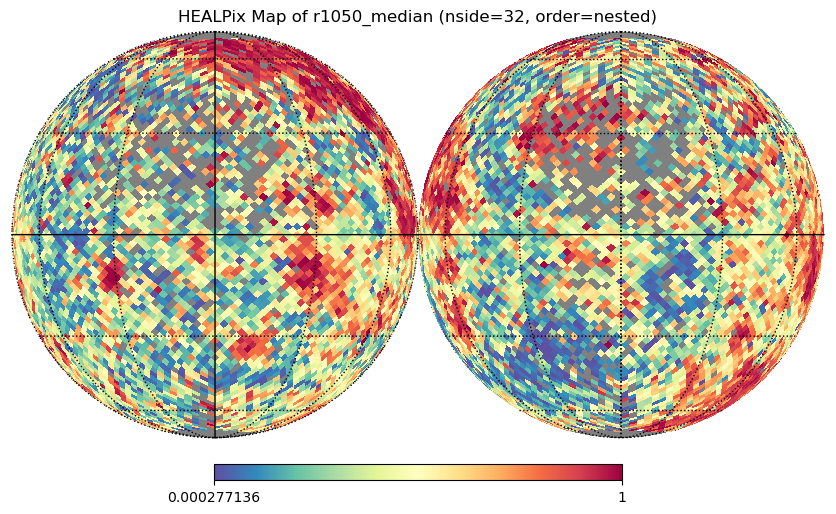

In [ ]:
#| eval: false
if HEALPY_AVAILABLE and 'aggregated_dense' in locals():
    # Prepare the map
    output_column = 'r1050_median'
    healpix_map, valid_pixels, invalid_pixels, mappable = prepare_healpix_map(
        aggregated_dense,
        output_column=output_column,
        equalize=True,
        cmap='Spectral_r'
    )
    
    # Plot with healpy
    order = 'nested'  # healpyxel default
    nest_flag = (order == 'nested')
    
    ax = healpy.visufunc.orthview(
        healpix_map,
        nest=nest_flag,
        title=f'HEALPix Map of {output_column} (nside={nside}, order={order})',
        cmap='Spectral_r',
        flip='geo',
        norm='None',
        xsize=2500
    )
    healpy.visufunc.graticule()
else:
    print("Skipping: healpy not available or no test data")

### Example 2: Multi-Panel Plot with Skyproj

Advanced visualization with multiple projections (Mollweide + polar views):

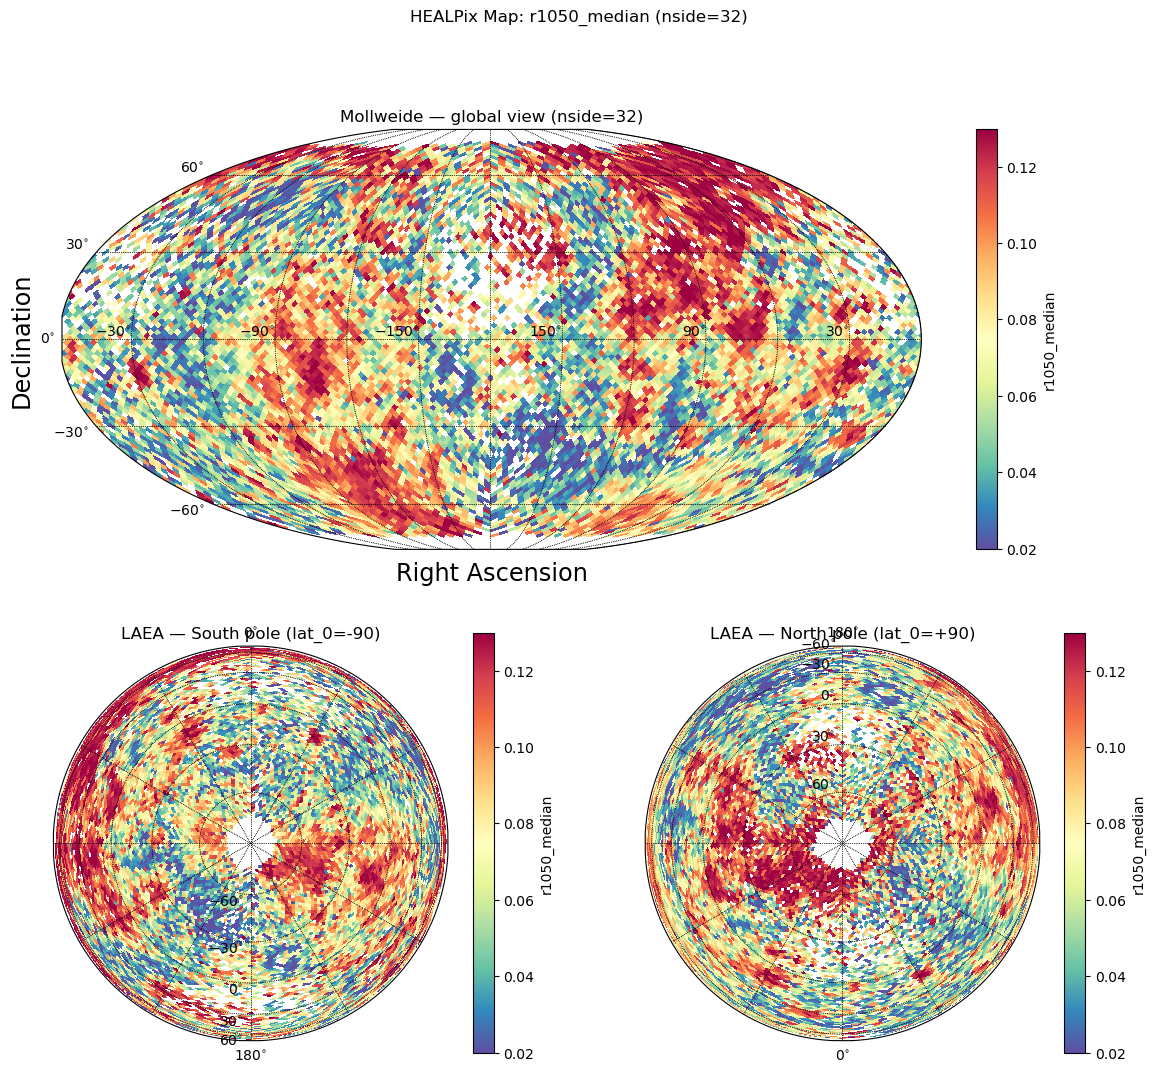

In [ ]:
#| eval: false
if SKYPROJ_AVAILABLE and HEALPY_AVAILABLE and 'aggregated_dense' in locals():
    from matplotlib import pyplot as plt
    
    # Prepare the map
    output_column = 'r1050_median'
    healpix_map, valid_pixels, invalid_pixels, mappable = prepare_healpix_map(
        aggregated_dense,
        output_column=output_column,
        equalize=True,
        cmap='Spectral_r'
    )
    
    # Mark invalid pixels for healpy
    healpix_map[invalid_pixels] = healpy.UNSEEN
    
    # Create figure with 3 panels
    fig = plt.figure(figsize=(14, 12))
    gs = fig.add_gridspec(2, 2, height_ratios=[1, 1])
    
    order = 'nested'
    nest_flag = (order == 'nested')
    
    # Top row: full-width Mollweide projection
    ax_top = fig.add_subplot(gs[0, :])
    sp_moll = skyproj.MollweideSkyproj(ax=ax_top, lon_0=-180, longitude_ticks='symmetric')
    _ = sp_moll.draw_hpxmap(
        healpix_map,
        nest=nest_flag,
        cmap='Spectral_r',
        zoom=True,
    )
    fig.colorbar(mappable, ax=sp_moll.ax, orientation='vertical', label=output_column)
    sp_moll.ax.set_title(f'Mollweide — global view (nside={nside})')
    
    # Bottom-left: LAEA centered on South pole
    ax_bl = fig.add_subplot(gs[1, 0])
    sp_south = skyproj.LaeaSkyproj(ax=ax_bl, lat_0=-90.0)
    _ = sp_south.draw_hpxmap(
        healpix_map,
        nest=nest_flag,
        cmap='Spectral_r',
        zoom=True,
    )
    fig.colorbar(mappable, ax=sp_south.ax, orientation='vertical', label=output_column)
    sp_south.ax.set_title('LAEA — South pole (lat_0=-90)')
    
    # Bottom-right: LAEA centered on North pole
    ax_br = fig.add_subplot(gs[1, 1])
    sp_north = skyproj.LaeaSkyproj(ax=ax_br, lat_0=90.0)
    _ = sp_north.draw_hpxmap(
        healpix_map,
        nest=nest_flag,
        cmap='Spectral_r',
        zoom=True,
    )
    fig.colorbar(mappable, ax=sp_north.ax, orientation='vertical', label=output_column)
    sp_north.ax.set_title('LAEA — North pole (lat_0=+90)')
    
    plt.suptitle(f'HEALPix Map: {output_column} (nside={nside})');
else:
    print("Skipping: skyproj/healpy not available or no test data")

### Example 3: Percentile Clipping

Remove extreme outliers before visualization:

In [ ]:
#| eval: false
if 'aggregated_dense' in locals():
    # Clip at 5% and 95% percentiles
    healpix_map, valid, invalid, mappable = prepare_healpix_map(
        aggregated_dense,
        output_column='r1050_median',
        equalize=True,
        percentile_cutoff=5  # Symmetric: [5%, 95%]
    )
    
    # Or asymmetric clipping
    healpix_map, valid, invalid, mappable = prepare_healpix_map(
        aggregated_dense,
        output_column='r1050_median',
        equalize=True,
        percentile_cutoff=(2, 98)  # Asymmetric: [2%, 98%]
    )
    
    print(f"✓ Prepared map with percentile clipping")
    print(f"  Valid pixels: {valid.sum()}")
    print(f"  Invalid pixels: {invalid.sum()}")
else:
    print("Skipping: no test data available")

✓ Prepared map with percentile clipping
  Valid pixels: 10825
  Invalid pixels: 1463


In [ ]:
#| hide
import nbdev; nbdev.nbdev_export()